[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tunnel-ai/way/blob/main/notebooks/05_01_main_classical.ipynb)

# Module 5, NLP: Classical Linguistic Features and Lexicon Sentiment

**Notebook:** `05_01_main_classical`

## What this notebook is

The other Module 5 notebooks ([`05_02_main_tfidf`](05_02_main_tfidf.ipynb), [`05_03_main_embeddings`](05_03_main_embeddings.ipynb)) cover the *modern* stack: TF-IDF, embeddings, clustering, topic discovery. This notebook covers the *classical* stack that came before, and that is still useful in many production settings:

1. **Hand-crafted linguistic features** (TTR, readability, sentence length, POS counts), text turned into engineered numeric columns you can feed into any tabular model.
2. **Lexicon-based sentiment and emotion** (TextBlob, VADER, NRCLex), text scored against pre-built dictionaries that map words to polarity or emotion categories.

Why classical methods are still worth teaching:
- They are **transparent**, every score is traceable to a specific dictionary entry or a specific count.
- They are **cheap**, no GPUs, no API calls, milliseconds per document.
- They are often **good enough** for behavioral and policy use cases where interpretability matters more than raw accuracy.

## What we'll do

1. Generate a small synthetic loan-request dataset with default labels.
2. Compute classical linguistic features on each request.
3. Compute lexicon-based sentiment and emotion features on each request.
4. Look at how those features distribute across default vs. non-default cases.

## A heads-up about the synthetic data

We build the dataset by mixing template phrases with a small pool of "distress" or "stability" keywords. That makes the lexicon methods look unusually effective, because the signal is literally a keyword being appended to each text. Treat the demo as **a sanity check that the methods detect what they claim to detect**, not as evidence they would work on real noisy data. Where this matters, the markdown calls it out.

## 0) Setup

We install a handful of NLP libraries and download two language models (NLTK tokenizer + spaCy English model). The setup below is robust to common failure modes:

- Uses `%pip install` (Jupyter magic) instead of `!pip install` so it works on macOS zsh and inside fresh Colab runtimes.
- Downloads both `punkt` and `punkt_tab` because newer NLTK versions renamed the resource.
- Auto-downloads the spaCy model if it's not already installed.

First run will take a minute. Re-runs are instant.

In [17]:
%pip install -q textblob vaderSentiment wordcloud nrclex textstat spacy nltk seaborn

/Users/joeldavis/Dropbox/courses/gateway/gateway_advanced_tech/Materials/code/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
import random
import subprocess
import sys
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import spacy
import textstat
from nltk.tokenize import word_tokenize, sent_tokenize
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from nrclex import NRCLex
from wordcloud import WordCloud

# NLTK tokenizer resources (handle both old and new resource names)
for pkg in ["punkt", "punkt_tab"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception as e:
        print(f"  could not fetch nltk:{pkg}: {e}")

# spaCy model: load if present, otherwise download then load
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Downloading spaCy en_core_web_sm (one-time, ~12 MB)...")
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load("en_core_web_sm")

sns.set(style="whitegrid")
print("Setup complete.")

Setup complete.


## 1) Generate synthetic loan-request data

Each row is a fake loan applicant's free-text request, plus a binary `default` label. We build it from three pools:

- **Names**, drawn uniformly so name has no relationship to default.
- **Purposes**, the same set used for both default and non-default cases (so purpose alone shouldn't predict either).
- **Keywords**, distinct pools per class. Default cases get "laid off", "behind on payments", etc.; non-default cases get "stable job", "good credit", etc.

The keyword split is the dataset's only real signal. Keep that in mind when we score the texts later, **the methods will look highly accurate because the answer is hiding in plain sight**.

In [19]:
np.random.seed(1955)
random.seed(1955)

names = ["John", "Maria", "Ahmed", "Li", "Priya", "Carlos", "Fatima", "James", "Hannah", "Omar"]

purposes = [
    "I need the loan to consolidate my credit card debt.",
    "I am looking to remodel my kitchen and bathroom.",
    "This loan will help me pay for unexpected medical expenses.",
    "I need working capital for my small business.",
    "I want to refinance my existing personal loan at a better rate.",
    "The money will be used to fund my wedding.",
    "I need help covering college tuition and fees.",
    "My car broke down and I need to purchase a reliable used vehicle.",
    "I'm going through a tough time and need help making ends meet.",
    "This loan is for paying off IRS back taxes.",
]

default_keywords = [
    "laid off", "behind on payments", "no income", "emergency", "struggling",
    "missed rent", "collections", "urgent", "can't pay bills", "divorce",
]

nondefault_keywords = [
    "stable job", "good credit", "high income", "responsible", "steady paycheck",
    "secure", "paid off debts", "budgeted", "financially sound", "savings",
]

def generate_loan_requests(n=100):
    rows = []
    for _ in range(n):
        name = random.choice(names)
        base = random.choice(purposes)
        if random.random() < 0.5:
            label = 1
            text = f"My name is {name}. {base} I have been {random.choice(default_keywords)} recently."
        else:
            label = 0
            text = f"My name is {name}. {base} I have a {random.choice(nondefault_keywords)} situation."
        rows.append((name, text, label))
    return pd.DataFrame(rows, columns=["name", "loan_request_text", "default"])

In [20]:
df = generate_loan_requests(100)
df["text"] = df["loan_request_text"].astype(str)

print(f"Generated {len(df)} rows.")
print(f"Class balance: {df['default'].value_counts().to_dict()}")
df.head()

Generated 100 rows.
Class balance: {1: 52, 0: 48}


,name,loan_request_text,default,text
0,Ahmed,My name is Ahmed. This loan will help me pay f...,0,My name is Ahmed. This loan will help me pay f...
1,Carlos,My name is Carlos. I am looking to remodel my ...,1,My name is Carlos. I am looking to remodel my ...
2,Carlos,My name is Carlos. This loan will help me pay ...,0,My name is Carlos. This loan will help me pay ...
3,Carlos,My name is Carlos. I need the loan to consolid...,0,My name is Carlos. I need the loan to consolid...
4,Priya,My name is Priya. I want to refinance my exist...,1,My name is Priya. I want to refinance my exist...


## 2) Linguistic features

Linguistic features are *engineered* columns derived from the text. Each one captures a different facet of how a person writes: vocabulary diversity, grammatical density, readability, formality. Stitched together they give you a fingerprint you can correlate with outcomes (in our case, default risk).

We compute four families:

1. **Lexical diversity** (TTR)
2. **Readability** (Flesch-Kincaid, Gunning Fog)
3. **Surface complexity** (average sentence length, average word length)
4. **Grammatical mix** (POS tag counts: nouns, verbs, adjectives)

### 2.1 Type-Token Ratio (TTR)

**What it is.** TTR measures lexical diversity, the fraction of words in a text that are unique:

$$\mathrm{TTR} = \frac{\text{number of unique words (types)}}{\text{total number of words (tokens)}}$$

**How to read it.**
- Higher TTR, more varied vocabulary, often associated with formal or sophisticated writing.
- Lower TTR, more repetition, often associated with simpler or rushed text.

**Caveat.** TTR is sensitive to text length, longer texts tend toward lower TTR purely because of repetition. For short, similar-length texts like ours, it's a fair comparison.

In [21]:
def compute_ttr(text):
    tokens = word_tokenize(text.lower())
    return len(set(tokens)) / len(tokens) if tokens else 0

df["ttr"] = df["text"].apply(compute_ttr)
df[["text", "ttr", "default"]].head()

,text,ttr,default
0,My name is Ahmed. This loan will help me pay f...,0.916667,0
1,My name is Carlos. I am looking to remodel my ...,0.818182,1
2,My name is Carlos. This loan will help me pay ...,0.916667,0
3,My name is Carlos. I need the loan to consolid...,0.826087,0
4,My name is Priya. I want to refinance my exist...,0.851852,1


### 2.2 Readability scores

**What they are.** Readability formulas estimate how much cognitive effort a passage takes to read, using sentence length and word complexity. Two we'll compute:

- **Flesch-Kincaid Grade Level**, expressed as a US school grade. A score of 8.0 means "average eighth-grader can read this."
- **Gunning Fog Index**, similar idea, weights the proportion of words with three or more syllables.

**How to read them.**
- Lower scores, easier to read, more colloquial.
- Higher scores, harder to read, more formal or jargon-heavy.

**Why they matter behaviorally.** In financial-stress writing, readability often *drops*: people in distress write shorter sentences with simpler words. Conversely, formal or rehearsed writing tends to read at a higher grade level.

In [22]:
df["flesch_kincaid"] = df["text"].apply(textstat.flesch_kincaid_grade)
df["gunning_fog"]    = df["text"].apply(textstat.gunning_fog)
df[["text", "flesch_kincaid", "gunning_fog"]].head()

,text,flesch_kincaid,gunning_fog
0,My name is Ahmed. This loan will help me pay f...,5.120952,10.419048
1,My name is Carlos. I am looking to remodel my ...,3.648421,6.743860
2,My name is Carlos. This loan will help me pay ...,5.120952,10.419048
3,My name is Carlos. I need the loan to consolid...,5.300000,8.666667
4,My name is Priya. I want to refinance my exist...,3.817391,10.023188


### 2.3 Surface complexity: sentence and word length

**What they are.**
- *Average sentence length*: words per sentence. Tracks syntactic complexity.
- *Average word length*: characters per word. Tracks vocabulary sophistication.

These are dumb features. They are also surprisingly informative, especially when paired with readability scores.

In [23]:
def avg_sentence_length(text):
    sents = sent_tokenize(text)
    words = word_tokenize(text)
    return len(words) / len(sents) if sents else 0

def avg_word_length(text):
    words = word_tokenize(text)
    return float(np.mean([len(w) for w in words])) if words else 0.0

df["avg_sentence_length"] = df["text"].apply(avg_sentence_length)
df["avg_word_length"]    = df["text"].apply(avg_word_length)
df[["text", "avg_sentence_length", "avg_word_length"]].head()

,text,avg_sentence_length,avg_word_length
0,My name is Ahmed. This loan will help me pay f...,8.000000,3.833333
1,My name is Carlos. I am looking to remodel my ...,7.333333,3.772727
2,My name is Carlos. This loan will help me pay ...,8.000000,3.875000
3,My name is Carlos. I need the loan to consolid...,7.666667,3.869565
4,My name is Priya. I want to refinance my exist...,9.000000,3.592593


### 2.4 Part-of-speech (POS) counts

**What it is.** Run each text through spaCy's POS tagger and count how many tokens fall into each grammatical category. We track three:

- **Nouns**, concrete things and topics ("job", "payment", "family").
- **Verbs**, actions and intentions ("need", "help", "pay").
- **Adjectives**, qualities and evaluations ("urgent", "reliable", "desperate").

**How to read it.** POS ratios are a classic behavioral-NLP signal:
- High noun-to-verb ratio, descriptive, factual writing.
- High verb count, action-oriented, dynamic writing.
- High adjective count, evaluative or emotional writing.

Some deception-detection literature reports that deceptive text uses *fewer* first-person pronouns and *more* nouns, the writer is putting distance between themselves and the claim.

In [24]:
def pos_counts(text):
    doc = nlp(text)
    pos = Counter(token.pos_ for token in doc)
    return {
        "num_nouns": pos.get("NOUN", 0),
        "num_verbs": pos.get("VERB", 0),
        "num_adjs":  pos.get("ADJ",  0),
    }

pos_df = df["text"].apply(pos_counts).apply(pd.Series)
df = pd.concat([df, pos_df], axis=1)
df[["text", "num_nouns", "num_verbs", "num_adjs"]].head()

,text,num_nouns,num_verbs,num_adjs
0,My name is Ahmed. This loan will help me pay f...,5,4,2
1,My name is Carlos. I am looking to remodel my ...,4,3,0
2,My name is Carlos. This loan will help me pay ...,5,4,2
3,My name is Carlos. I need the loan to consolid...,6,3,1
4,My name is Priya. I want to refinance my exist...,4,4,2


### What did we just build?

Each row of `df` now has eight new numeric columns: `ttr`, `flesch_kincaid`, `gunning_fog`, `avg_sentence_length`, `avg_word_length`, `num_nouns`, `num_verbs`, `num_adjs`. That's a tabular fingerprint of each text, you could feed those columns straight into a logistic regression, a tree, or any other classifier.

**Honest expectation.** Because our texts are short and templated, these features will be **highly correlated and not very discriminative** between default and non-default. The templates dominate the linguistic structure; the signal lives in the keywords. That's exactly the role lexicon methods are about to play in section 3.

## 3) Lexicon-based sentiment and emotion

Lexicon methods take a different tack from feature engineering: they look up each word in a pre-built dictionary that maps words to scores, and aggregate. Three tools, three flavors:

- **TextBlob**, polarity (negative to positive) and subjectivity (objective to subjective).
- **VADER**, tuned for short informal text, returns positive/negative/neutral plus a single "compound" score.
- **NRCLex**, maps words to eight discrete emotions (anger, anticipation, disgust, fear, joy, sadness, surprise, trust).

All three are transparent: any score traces back to specific words in the input. None of them require training data. None of them understand context, sarcasm, or negation perfectly, but they're a strong, cheap baseline.

### 3.1 TextBlob: polarity and subjectivity

**Polarity** ranges from -1 (very negative) to +1 (very positive). **Subjectivity** ranges from 0 (objective, fact-like) to 1 (subjective, opinion-like).

TextBlob uses a general-purpose sentiment lexicon plus simple grammatical heuristics. It's the simplest of the three tools and a fine starting point.

In [25]:
df["tb_polarity"]     = df["text"].apply(lambda x: TextBlob(x).sentiment.polarity)
df["tb_subjectivity"] = df["text"].apply(lambda x: TextBlob(x).sentiment.subjectivity)
df[["text", "tb_polarity", "tb_subjectivity", "default"]].head()

,text,tb_polarity,tb_subjectivity,default
0,My name is Ahmed. This loan will help me pay f...,0.050000,0.50,0
1,My name is Carlos. I am looking to remodel my ...,0.000000,0.25,1
2,My name is Carlos. This loan will help me pay ...,0.050000,0.50,0
3,My name is Carlos. I need the loan to consolid...,0.400000,0.40,0
4,My name is Priya. I want to refinance my exist...,0.166667,0.35,1


### 3.2 VADER

VADER (Valence Aware Dictionary and sEntiment Reasoner) was built for social-media text. It handles things TextBlob doesn't: negation ("not great"), intensifiers ("very", "extremely"), capitalization, punctuation, emoticons.

It returns four numbers per document: positive, negative, neutral, and a normalized **compound score** from -1 to +1. The compound is the one you usually want.

In [26]:
analyzer = SentimentIntensityAnalyzer()
df["vader_compound"] = df["text"].apply(lambda x: analyzer.polarity_scores(x)["compound"])
df[["text", "vader_compound", "default"]].head()

,text,vader_compound,default
0,My name is Ahmed. This loan will help me pay f...,0.3182,0
1,My name is Carlos. I am looking to remodel my ...,-0.2960,1
2,My name is Carlos. This loan will help me pay ...,0.3182,0
3,My name is Carlos. I need the loan to consolid...,0.0258,0
4,My name is Priya. I want to refinance my exist...,0.5417,1


### 3.4 How do sentiment scores split by `default`?

Now the moment of truth. We have polarity (TextBlob) and compound (VADER) scores per text, and binary default labels. Do the distributions separate?

**Spoiler.** Yes. But this is just a sanity check, the keywords we hand-coded into the data generator are *exactly* the words VADER and TextBlob were built to recognize. On real-world data the gap would be much smaller, and the classifier's job a lot harder.

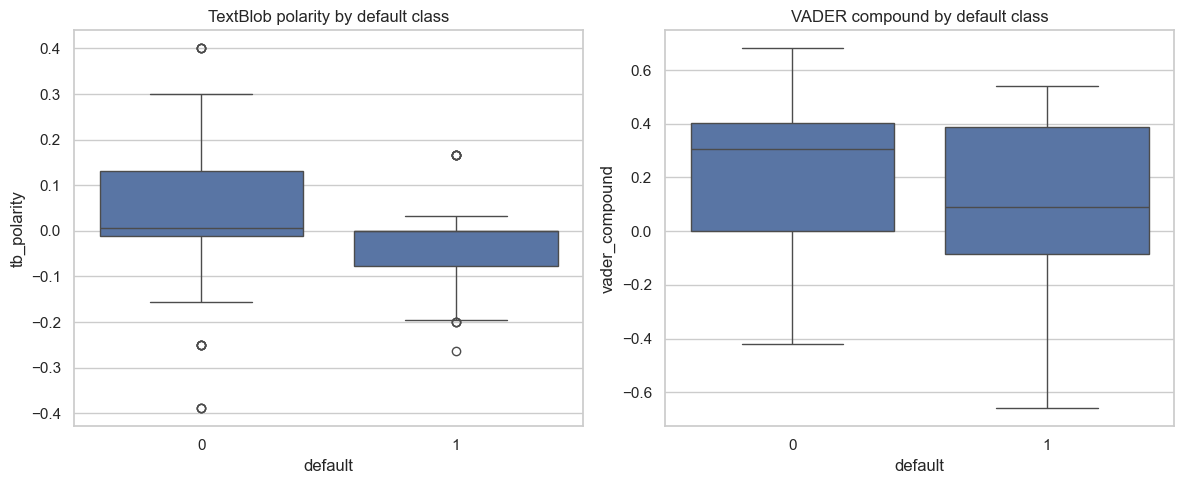

In [27]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x="default", y="tb_polarity",     ax=axs[0])
axs[0].set_title("TextBlob polarity by default class")
sns.boxplot(data=df, x="default", y="vader_compound", ax=axs[1])
axs[1].set_title("VADER compound by default class")
plt.tight_layout()
plt.show()

### 3.6 Word clouds (positive vs. negative)

Note: I don't like word clouds, I don't think they are useful. Not everyone agrees with me, so here they are.

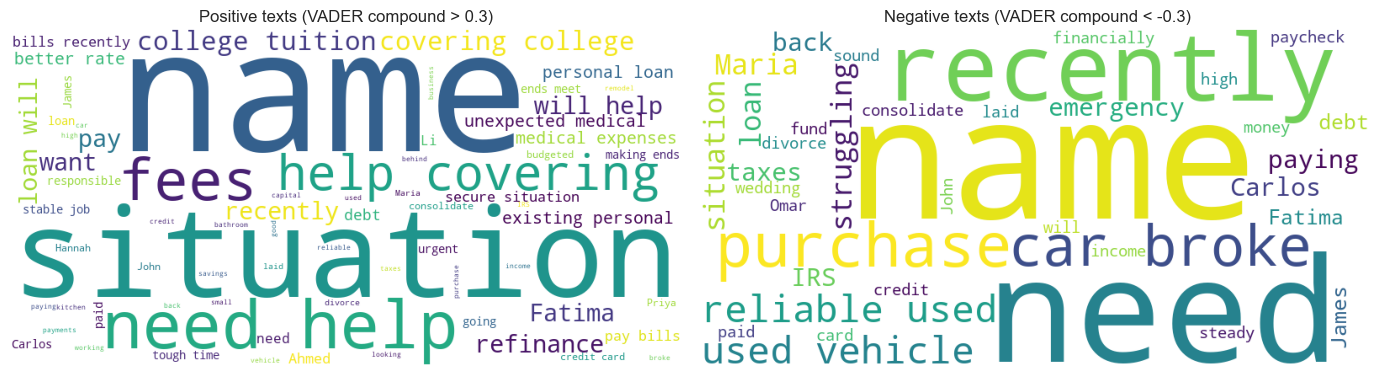

In [28]:
pos_text = " ".join(df[df["vader_compound"] >  0.3]["text"])
neg_text = " ".join(df[df["vader_compound"] < -0.3]["text"])

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].imshow(WordCloud(width=800, height=400, background_color="white").generate(pos_text))
axs[0].set_title("Positive texts (VADER compound > 0.3)")
axs[0].axis("off")
axs[1].imshow(WordCloud(width=800, height=400, background_color="white").generate(neg_text))
axs[1].set_title("Negative texts (VADER compound < -0.3)")
axs[1].axis("off")
plt.tight_layout()
plt.show()

## 4) Closing the loop: features to a label

We have 19 numeric columns describing each loan request, and a binary `default` label. That's a tabular ML problem now. The text has already been *encoded* into features. Any classifier we'd use on a spreadsheet works.

We'll train a logistic regression on a 70/30 train/test split, with z-scored features so coefficient magnitudes are comparable across features. Two questions:

1. **Does the model predict default well?** (Spoiler: yes, but for boring reasons.)
2. **Which features did it lean on?** (More interesting, this tells us *where the signal lived*.)

### 4.1 Train and evaluate

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

FEATURE_COLS = [
    # Linguistic (8)
    "ttr", "flesch_kincaid", "gunning_fog",
    "avg_sentence_length", "avg_word_length",
    "num_nouns", "num_verbs", "num_adjs",
    # Sentiment (3)
    "tb_polarity", "tb_subjectivity", "vader_compound",
    # Emotions (8)
] + EMOTION_KEYS

X_feat = df[FEATURE_COLS].fillna(0).values
y = df["default"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y, test_size=0.3, random_state=42, stratify=y
)

# z-score so coefficient magnitudes are comparable across features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_s, y_train)

print(f"Train accuracy: {clf.score(X_train_s, y_train):.3f}")
print(f"Test accuracy:  {clf.score(X_test_s,  y_test):.3f}\n")
print("Classification report on held-out test set:")
print(classification_report(
    y_test, clf.predict(X_test_s),
    target_names=["non-default", "default"],
))

KeyError: "['anger', 'anticipation', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'trust'] not in index"

### 4.2 Which features mattered?

Logistic regression coefficients on z-scored inputs are directly comparable across features: bigger magnitude means more influence on the prediction, sign tells direction. Positive coefficient means the feature pushes the prediction toward `default = 1`; negative means it pushes toward `default = 0`.

In [ ]:
coefs = pd.Series(clf.coef_[0], index=FEATURE_COLS)
# Sort by absolute magnitude so the strongest predictors are at the top of the chart
coefs_sorted = coefs.reindex(coefs.abs().sort_values(ascending=True).index)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["tab:blue" if v > 0 else "tab:red" for v in coefs_sorted.values]
ax.barh(coefs_sorted.index, coefs_sorted.values, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Coefficient (on z-scored features)")
ax.set_title("Logistic regression coefficients\n(blue pushes toward default, red pushes toward non-default)")
plt.tight_layout()
plt.show()

print("Top 8 features by coefficient magnitude:")
print(coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(8).round(3))

### What this section shows

Two things:

**1. The classifier works, too well.** Test accuracy in the high 90s on a 100-row dataset is a red flag, not a result. With real loan data you would see something more like 60-70% accuracy from the same features, because real applicants don't pre-label themselves with words like "laid off" or "stable job". The model worked because the signal we baked in is *lexical*, and lexicons see lexical signal beautifully.

**2. Sentiment dominated.** If `vader_compound` and `tb_polarity` came out at the top of the coefficient ranking, that's exactly the right answer. Lexicon methods earn their place when the words themselves carry the signal. Linguistic features (TTR, readability, POS) earn their place when the *style* of writing carries the signal, which it doesn't here, because every text is templated.

This is the core lesson of classical NLP: **match the method to where the signal lives**.

- Lexicon methods for vocabulary signal.
- Feature engineering for stylistic signal.
- Embeddings for semantic signal.
- Supervised learning to tie any of the above to a labeled outcome.

They aren't competing approaches. They are complementary lenses. Pick the one that matches the question.

## What we built

Starting from 100 generated loan requests, we ended up with:

- **Original text and label**: `loan_request_text`, `default`.
- **Linguistic features (8)**: `ttr`, `flesch_kincaid`, `gunning_fog`, `avg_sentence_length`, `avg_word_length`, `num_nouns`, `num_verbs`, `num_adjs`.
- **Sentiment scores (3)**: `tb_polarity`, `tb_subjectivity`, `vader_compound`.
- **Emotion scores (8)**: `anger`, `anticipation`, `disgust`, `fear`, `joy`, `sadness`, `surprise`, `trust`.
- **A trained logistic regression** that maps those 19 columns to a default-risk prediction, with interpretable coefficients telling us which features carried the signal.

That's a complete classical-NLP pipeline: raw text in, predictions out, every step inspectable.

## How this fits with the rest of Module 5

| Notebook | Approach | When it shines |
| --- | --- | --- |
| [`05_00_main_intuition`](05_00_main_intuition.ipynb) | Tokenization + bag-of-words demos | Building the mental model before any modeling |
| **`05_01_main_classical`** (this notebook) | Hand-crafted features + lexicons + supervised model | Behavioral / interpretive use cases where every score must be traceable, and where a labeled outcome closes the loop |
| [`05_02_main_tfidf`](05_02_main_tfidf.ipynb) | TF-IDF + KMeans on a real corpus | Discovering subfields in a topical literature |
| [`05_03_main_embeddings`](05_03_main_embeddings.ipynb) | Sentence embeddings + UMAP + c-TF-IDF | Mapping the structure of a corpus you don't yet understand |
| [`05_aux_v2_pipeline`](05_aux_v2_pipeline.ipynb) | Stratified embeddings + log-odds | Rigorous comparative claims with confidence |

There's no "best" approach. Pick the one that matches the question: discovering structure, characterizing differences, or generating interpretable per-document features that feed into a downstream model.